# DESI Spectra Embeddings Visualization

This notebook visualizes the embeddings extracted from DESI spectra using the trained AstroPT model.

We use dimensionality reduction techniques (UMAP and t-SNE) to project the high-dimensional embeddings into 2D space for visualization.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configure matplotlib
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

## 1. Load Embeddings

First, load the extracted embeddings and associated metadata (target IDs and redshifts).

In [2]:
# Paths to saved embeddings (update these paths as needed)
embeddings_file = "desi_embeddings.npy"
targetids_file = "desi_targetids.npy"
redshifts_file = "desi_redshifts.npy"

# Load data
print("Loading embeddings...")
embeddings = np.load(embeddings_file)
target_ids = np.load(targetids_file)
redshifts = np.load(redshifts_file)

print(f"Embeddings shape: {embeddings.shape}")
print(f"Number of spectra: {len(target_ids)}")
print(f"Embedding dimension: {embeddings.shape[1]}")
print(f"Redshift range: [{redshifts.min():.3f}, {redshifts.max():.3f}]")

Loading embeddings...
Embeddings shape: (754064, 768)
Number of spectra: 754064
Embedding dimension: 768
Redshift range: [0.001, 0.722]


## 1.1 Load Physical Properties from Catalog

Load the DESI catalog to get physical properties (stellar mass, SFR, DN4000, emission lines, colors) for each spectrum.

In [ ]:
from astropy.io import fits
from astropy.table import Table

# Path to DESI catalog
catalog_path = "/pbs/throng/training/astroinfo2025/data/astroPT_desi_dataset/DESI_dataset_catalog.fits"

print("Loading DESI catalog...")
with fits.open(catalog_path) as hdul:
    catalog = Table(hdul[1].data)

print(f"Catalog loaded: {len(catalog)} entries")
print(f"Available columns: {len(catalog.colnames)}")

# Create a mapping from TARGETID to catalog index for fast lookup
targetid_to_idx = {tid: i for i, tid in enumerate(catalog['TARGETID'])}

# Match embeddings to catalog entries
matched_indices = []
unmatched_count = 0

for tid in target_ids:
    if tid in targetid_to_idx:
        matched_indices.append(targetid_to_idx[tid])
    else:
        matched_indices.append(-1)  # Mark as unmatched
        unmatched_count += 1

matched_indices = np.array(matched_indices)
print(f"\nMatched {len(matched_indices) - unmatched_count}/{len(target_ids)} spectra to catalog")
if unmatched_count > 0:
    print(f"Warning: {unmatched_count} spectra not found in catalog")

# Extract physical properties (handle unmatched with NaN)
def safe_extract(column_name):
    """Extract column values, filling unmatched entries with NaN"""
    values = np.full(len(matched_indices), np.nan, dtype=float)
    mask = matched_indices >= 0
    values[mask] = catalog[column_name][matched_indices[mask]]
    return values

# Key physical properties
logm = safe_extract('LOGM')              # Stellar mass (log solar masses)
logsfr = safe_extract('LOGSFR')          # Star formation rate (log Msun/yr)
dn4000 = safe_extract('DN4000')          # 4000Å break (stellar age indicator)

# Emission line fluxes
halpha_flux = safe_extract('HALPHA_FLUX')
hbeta_flux = safe_extract('HBETA_FLUX')

# Photometric colors
uv_color = safe_extract('UV')            # U-V color
vj_color = safe_extract('VJ')            # V-J color
gr_color = safe_extract('GR')            # g-r color

# AGN properties
agn_lum = safe_extract('AGNLUM')
agn_frac = safe_extract('AGNFRAC')

print("\nPhysical property statistics:")
print(f"  LOGM (stellar mass): {np.nanmean(logm):.2f} ± {np.nanstd(logm):.2f}")
print(f"  LOGSFR: {np.nanmean(logsfr):.2f} ± {np.nanstd(logsfr):.2f}")
print(f"  DN4000: {np.nanmean(dn4000):.2f} ± {np.nanstd(dn4000):.2f}")
print(f"  g-r color: {np.nanmean(gr_color):.2f} ± {np.nanstd(gr_color):.2f}")

# Calculate derived properties
# Specific SFR (sSFR = SFR / M*)
ssfr = logsfr - logm
print(f"  sSFR (log): {np.nanmean(ssfr):.2f} ± {np.nanstd(ssfr):.2f}")

# Emission line ratio (Hα/Hβ, Balmer decrement for star-forming galaxies)
# Valid ratio should be > 2.86 (intrinsic), lower indicates dust attenuation
halpha_hbeta_ratio = np.full(len(halpha_flux), np.nan)
valid_mask = (hbeta_flux > 0) & (halpha_flux > 0)
halpha_hbeta_ratio[valid_mask] = halpha_flux[valid_mask] / hbeta_flux[valid_mask]
print(f"  Hα/Hβ ratio: {np.nanmedian(halpha_hbeta_ratio):.2f} (median)")

## 2. Basic Statistics

Examine the distribution of redshifts and embedding statistics.

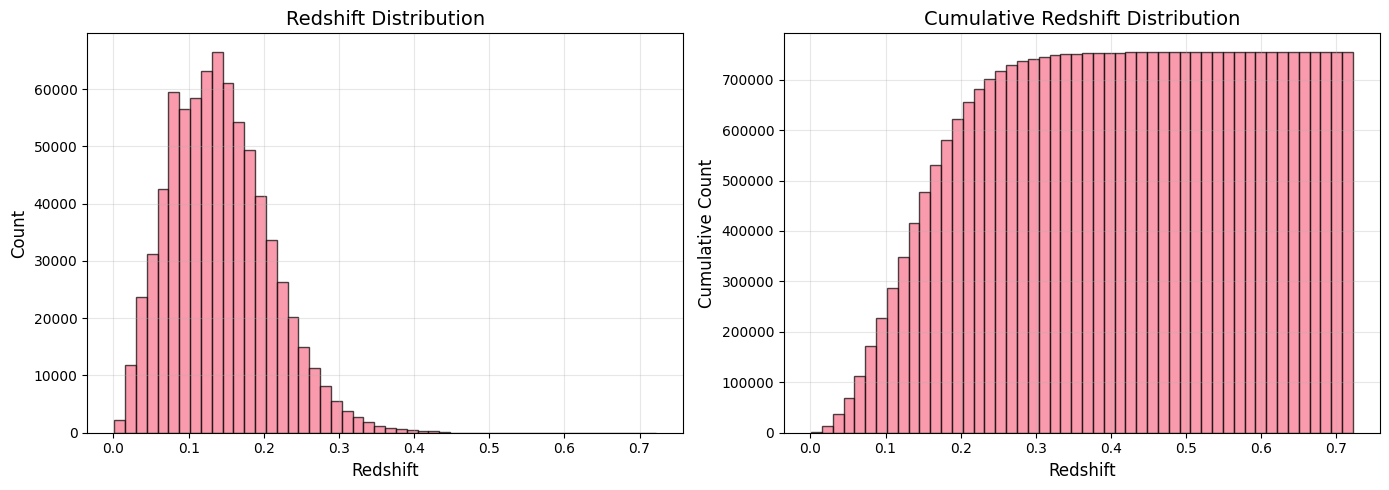


Redshift statistics:
  Mean: 0.142
  Median: 0.137
  Std: 0.066


In [3]:
# Plot redshift distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(redshifts, bins=50, alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Redshift', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Redshift Distribution', fontsize=14)
axes[0].grid(alpha=0.3)

# Cumulative distribution
axes[1].hist(redshifts, bins=50, cumulative=True, alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Redshift', fontsize=12)
axes[1].set_ylabel('Cumulative Count', fontsize=12)
axes[1].set_title('Cumulative Redshift Distribution', fontsize=14)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print(f"\nRedshift statistics:")
print(f"  Mean: {redshifts.mean():.3f}")
print(f"  Median: {np.median(redshifts):.3f}")
print(f"  Std: {redshifts.std():.3f}")

## 3. UMAP Dimensionality Reduction

Use UMAP (Uniform Manifold Approximation and Projection) to reduce embeddings to 2D.
UMAP is particularly good at preserving both local and global structure.

In [5]:
import umap
import time

print("Running UMAP dimensionality reduction...")
print("This may take a few minutes...")

# Configure UMAP
umap_model = umap.UMAP(
    n_neighbors=15,      # Size of local neighborhood
    min_dist=0.1,        # Minimum distance between points in low-dim space
    n_components=2,      # Target dimensions
    metric='cosine',     # Distance metric (cosine is good for embeddings)
    random_state=42      # For reproducibility
)

# Fit and transform
start_time = time.time()
embeddings_umap = umap_model.fit_transform(embeddings)
elapsed = time.time() - start_time

print(f"✓ UMAP completed in {elapsed:.2f} seconds")
print(f"UMAP embeddings shape: {embeddings_umap.shape}")

Running UMAP dimensionality reduction...
This may take a few minutes...


/pbs/throng/training/astroinfo2025/env/astroPT/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✓ UMAP completed in 552.02 seconds
UMAP embeddings shape: (754064, 2)


## 4. Visualize UMAP Results

Plot the 2D UMAP projection, colored by redshift.

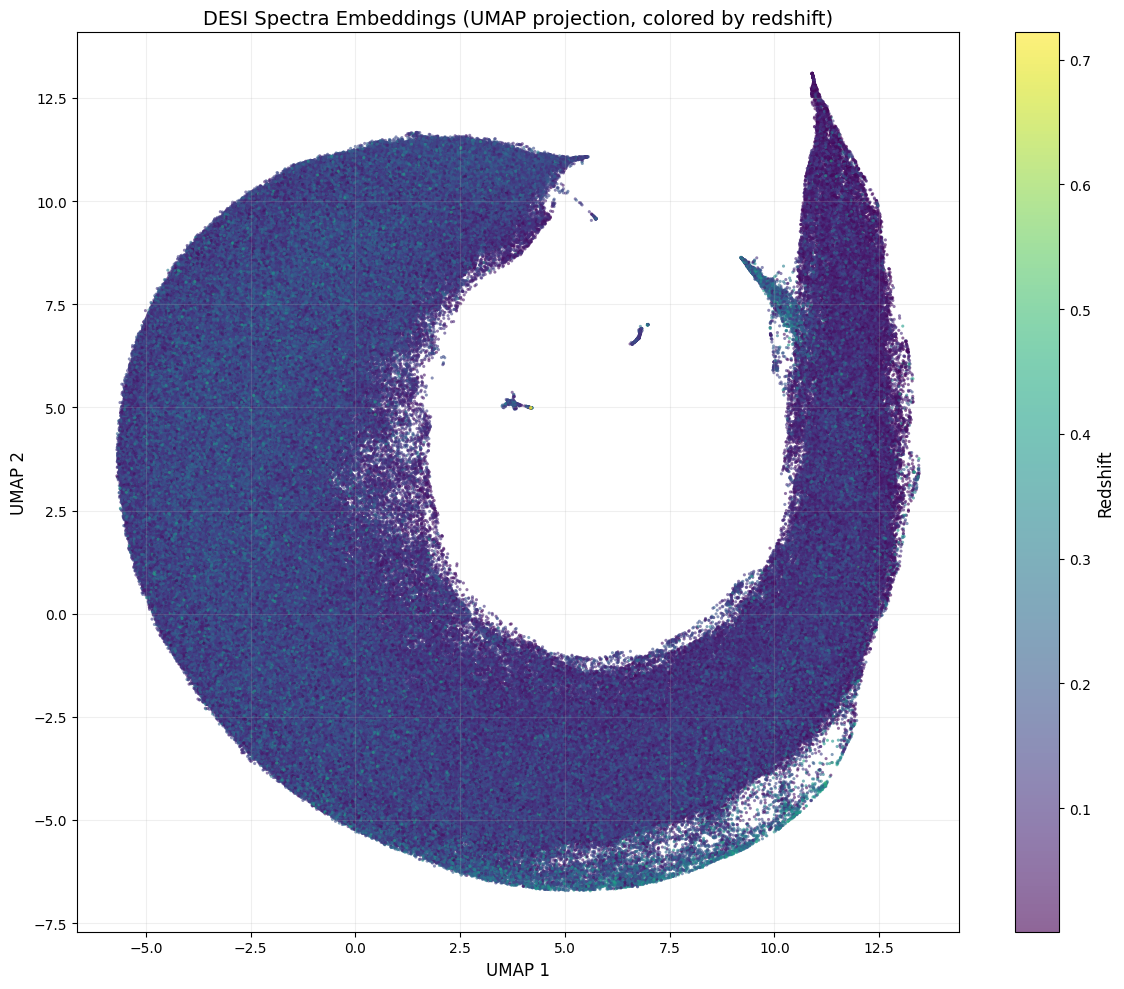

Saved: umap_desi_embeddings_redshift.png


In [6]:
fig, ax = plt.subplots(figsize=(12, 10))

# Create scatter plot colored by redshift
scatter = ax.scatter(
    embeddings_umap[:, 0],
    embeddings_umap[:, 1],
    c=redshifts,
    cmap='viridis',
    s=5,
    alpha=0.6,
    edgecolors='none'
)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Redshift', fontsize=12)

ax.set_xlabel('UMAP 1', fontsize=12)
ax.set_ylabel('UMAP 2', fontsize=12)
ax.set_title('DESI Spectra Embeddings (UMAP projection, colored by redshift)', fontsize=14)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('umap_desi_embeddings_redshift.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: umap_desi_embeddings_redshift.png")

## 4.1 Visualize by Stellar Mass (LOGM)

Color the embeddings by stellar mass to check if the model learns mass-dependent features.

In [ ]:
fig, ax = plt.subplots(figsize=(12, 10))

# Filter out NaN values for cleaner visualization
valid_mask = ~np.isnan(logm)

scatter = ax.scatter(
    embeddings_umap[valid_mask, 0],
    embeddings_umap[valid_mask, 1],
    c=logm[valid_mask],
    cmap='plasma',
    s=5,
    alpha=0.6,
    edgecolors='none',
    vmin=np.nanpercentile(logm, 2),
    vmax=np.nanpercentile(logm, 98)
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('log(M*/M☉) - Stellar Mass', fontsize=12)

ax.set_xlabel('UMAP 1', fontsize=12)
ax.set_ylabel('UMAP 2', fontsize=12)
ax.set_title('DESI Embeddings colored by Stellar Mass (LOGM)', fontsize=14)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('umap_desi_embeddings_logm.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: umap_desi_embeddings_logm.png")
print(f"Valid data points: {valid_mask.sum()}/{len(logm)}")

## 4.2 Visualize by Star Formation Rate (LOGSFR)

Color the embeddings by star formation rate to check if the model learns SFR-dependent features.

In [ ]:
fig, ax = plt.subplots(figsize=(12, 10))

valid_mask = ~np.isnan(logsfr)

scatter = ax.scatter(
    embeddings_umap[valid_mask, 0],
    embeddings_umap[valid_mask, 1],
    c=logsfr[valid_mask],
    cmap='coolwarm',
    s=5,
    alpha=0.6,
    edgecolors='none',
    vmin=np.nanpercentile(logsfr, 2),
    vmax=np.nanpercentile(logsfr, 98)
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('log(SFR) [M☉/yr] - Star Formation Rate', fontsize=12)

ax.set_xlabel('UMAP 1', fontsize=12)
ax.set_ylabel('UMAP 2', fontsize=12)
ax.set_title('DESI Embeddings colored by Star Formation Rate (LOGSFR)', fontsize=14)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('umap_desi_embeddings_logsfr.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: umap_desi_embeddings_logsfr.png")
print(f"Valid data points: {valid_mask.sum()}/{len(logsfr)}")

## 4.3 Visualize by DN4000 (Stellar Age Indicator)

DN4000 is the 4000Å break strength - higher values indicate older stellar populations.
This tests if the model learns spectral features related to stellar age.

In [ ]:
fig, ax = plt.subplots(figsize=(12, 10))

valid_mask = ~np.isnan(dn4000)

scatter = ax.scatter(
    embeddings_umap[valid_mask, 0],
    embeddings_umap[valid_mask, 1],
    c=dn4000[valid_mask],
    cmap='RdYlBu_r',  # Red (old) to Blue (young)
    s=5,
    alpha=0.6,
    edgecolors='none',
    vmin=np.nanpercentile(dn4000, 2),
    vmax=np.nanpercentile(dn4000, 98)
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('DN4000 (4000Å break strength)', fontsize=12)

ax.set_xlabel('UMAP 1', fontsize=12)
ax.set_ylabel('UMAP 2', fontsize=12)
ax.set_title('DESI Embeddings colored by DN4000 (Stellar Age)', fontsize=14)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('umap_desi_embeddings_dn4000.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: umap_desi_embeddings_dn4000.png")
print(f"Valid data points: {valid_mask.sum()}/{len(dn4000)}")
print(f"DN4000 range: [{np.nanmin(dn4000):.2f}, {np.nanmax(dn4000):.2f}]")

## 4.4 Visualize by Specific Star Formation Rate (sSFR)

sSFR = SFR/M* measures star-forming efficiency. High sSFR indicates actively star-forming galaxies,
low sSFR indicates passive/quenched galaxies. This tests if the model separates galaxy evolutionary states.

In [ ]:
fig, ax = plt.subplots(figsize=(12, 10))

valid_mask = ~np.isnan(ssfr)

scatter = ax.scatter(
    embeddings_umap[valid_mask, 0],
    embeddings_umap[valid_mask, 1],
    c=ssfr[valid_mask],
    cmap='coolwarm',
    s=5,
    alpha=0.6,
    edgecolors='none',
    vmin=np.nanpercentile(ssfr, 2),
    vmax=np.nanpercentile(ssfr, 98)
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('log(sSFR) [yr⁻¹] - Specific SFR', fontsize=12)

ax.set_xlabel('UMAP 1', fontsize=12)
ax.set_ylabel('UMAP 2', fontsize=12)
ax.set_title('DESI Embeddings colored by Specific Star Formation Rate', fontsize=14)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('umap_desi_embeddings_ssfr.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: umap_desi_embeddings_ssfr.png")
print(f"Valid data points: {valid_mask.sum()}/{len(ssfr)}")

## 4.5 Visualize by g-r Color (Galaxy Type)

g-r color separates red (passive, old) galaxies from blue (star-forming, young) galaxies.
This is a classic bimodality in galaxy populations.

In [ ]:
fig, ax = plt.subplots(figsize=(12, 10))

valid_mask = ~np.isnan(gr_color)

scatter = ax.scatter(
    embeddings_umap[valid_mask, 0],
    embeddings_umap[valid_mask, 1],
    c=gr_color[valid_mask],
    cmap='RdBu_r',  # Red galaxies in red, blue galaxies in blue
    s=5,
    alpha=0.6,
    edgecolors='none',
    vmin=np.nanpercentile(gr_color, 2),
    vmax=np.nanpercentile(gr_color, 98)
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('g-r Color [mag]', fontsize=12)

ax.set_xlabel('UMAP 1', fontsize=12)
ax.set_ylabel('UMAP 2', fontsize=12)
ax.set_title('DESI Embeddings colored by g-r Color (Red vs Blue Galaxies)', fontsize=14)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('umap_desi_embeddings_gr_color.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: umap_desi_embeddings_gr_color.png")
print(f"Valid data points: {valid_mask.sum()}/{len(gr_color)}")

## 4.6 Visualize by Hα/Hβ Ratio (Balmer Decrement)

The Hα/Hβ flux ratio (Balmer decrement) is sensitive to dust attenuation and star formation activity.
Intrinsic ratio ~2.86 for star-forming regions; higher values indicate dust reddening.

In [ ]:
fig, ax = plt.subplots(figsize=(12, 10))

valid_mask = ~np.isnan(halpha_hbeta_ratio) & (halpha_hbeta_ratio > 0)

# Clip extreme outliers for better visualization
ratio_clipped = np.clip(halpha_hbeta_ratio[valid_mask], 1, 10)

scatter = ax.scatter(
    embeddings_umap[valid_mask, 0],
    embeddings_umap[valid_mask, 1],
    c=ratio_clipped,
    cmap='viridis',
    s=5,
    alpha=0.6,
    edgecolors='none'
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Hα/Hβ Flux Ratio (Balmer Decrement)', fontsize=12)

# Add reference line for intrinsic ratio
ax.text(0.02, 0.98, 'Intrinsic ratio ≈ 2.86\nHigher → more dust', 
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

ax.set_xlabel('UMAP 1', fontsize=12)
ax.set_ylabel('UMAP 2', fontsize=12)
ax.set_title('DESI Embeddings colored by Hα/Hβ Ratio (Dust Indicator)', fontsize=14)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('umap_desi_embeddings_balmer.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Saved: umap_desi_embeddings_balmer.png")
print(f"Valid data points: {valid_mask.sum()}/{len(halpha_hbeta_ratio)}")
print(f"Ratio median: {np.nanmedian(halpha_hbeta_ratio):.2f}")

## 5. Redshift Binning

Visualize different redshift bins separately to see how the embedding space is organized.

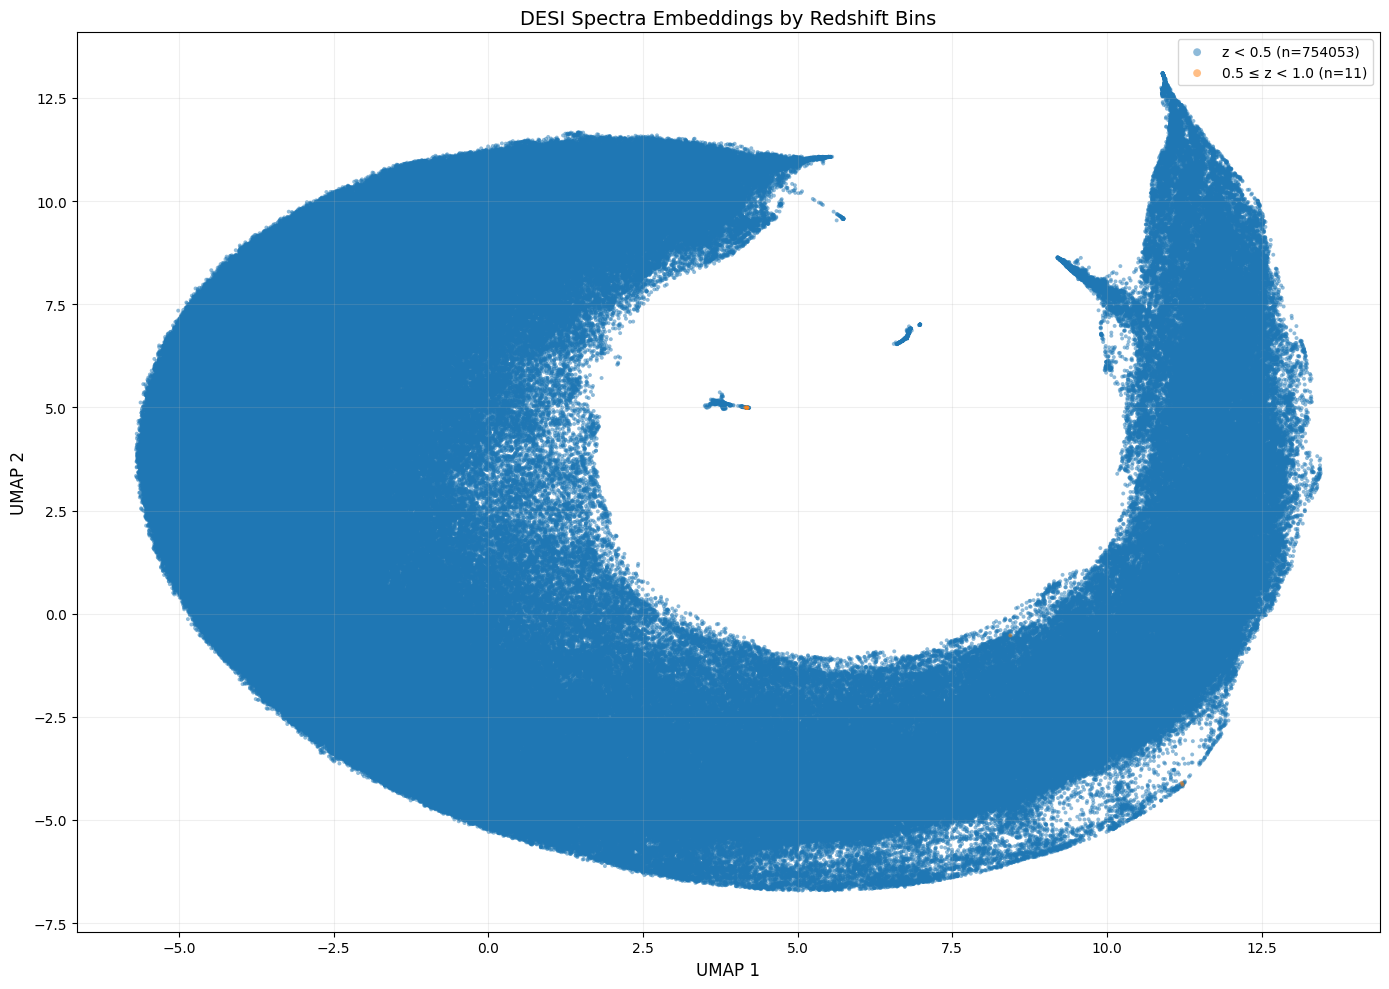

Saved: umap_desi_embeddings_bins.png


In [7]:
# Define redshift bins
z_bins = [0, 0.5, 1.0, 1.5, 2.0, np.inf]
z_labels = ['z < 0.5', '0.5 ≤ z < 1.0', '1.0 ≤ z < 1.5', '1.5 ≤ z < 2.0', 'z ≥ 2.0']
colors_bins = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# Assign each spectrum to a bin
z_bin_indices = np.digitize(redshifts, z_bins) - 1

fig, ax = plt.subplots(figsize=(14, 10))

# Plot each bin with different color
for i, label in enumerate(z_labels):
    mask = z_bin_indices == i
    if mask.sum() > 0:
        ax.scatter(
            embeddings_umap[mask, 0],
            embeddings_umap[mask, 1],
            c=colors_bins[i],
            label=f'{label} (n={mask.sum()})',
            s=8,
            alpha=0.5,
            edgecolors='none'
        )

ax.set_xlabel('UMAP 1', fontsize=12)
ax.set_ylabel('UMAP 2', fontsize=12)
ax.set_title('DESI Spectra Embeddings by Redshift Bins', fontsize=14)
ax.legend(loc='best', fontsize=10, markerscale=2)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('umap_desi_embeddings_bins.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: umap_desi_embeddings_bins.png")

## 6. t-SNE Dimensionality Reduction (Optional)

t-SNE is another popular dimensionality reduction technique. It's good at preserving local structure
but can be slower than UMAP for large datasets.

In [ ]:
from sklearn.manifold import TSNE

print("Running t-SNE dimensionality reduction...")
print("This may take several minutes for large datasets...")

# Configure t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    max_iter=1000,
    random_state=42,
    verbose=1
)

# Fit and transform (may take a while)
start_time = time.time()
embeddings_tsne = tsne.fit_transform(embeddings)
elapsed = time.time() - start_time

print(f"✓ t-SNE completed in {elapsed:.2f} seconds")
print(f"t-SNE embeddings shape: {embeddings_tsne.shape}")

Running t-SNE dimensionality reduction...
This may take several minutes for large datasets...


TypeError: TSNE.__init__() got an unexpected keyword argument 'n_iter'

## 7. Visualize t-SNE Results

In [ ]:
fig, ax = plt.subplots(figsize=(12, 10))

# Create scatter plot colored by redshift
scatter = ax.scatter(
    embeddings_tsne[:, 0],
    embeddings_tsne[:, 1],
    c=redshifts,
    cmap='viridis',
    s=5,
    alpha=0.6,
    edgecolors='none'
)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Redshift', fontsize=12)

ax.set_xlabel('t-SNE 1', fontsize=12)
ax.set_ylabel('t-SNE 2', fontsize=12)
ax.set_title('DESI Spectra Embeddings (t-SNE projection, colored by redshift)', fontsize=14)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('tsne_desi_embeddings_redshift.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: tsne_desi_embeddings_redshift.png")

## 7.1 t-SNE colored by Physical Properties

Now visualize the t-SNE projections colored by the same physical properties for comparison.

In [ ]:
# Create a 2x3 grid of t-SNE plots with different physical properties
fig, axes = plt.subplots(2, 3, figsize=(20, 13))
axes = axes.flatten()

# Property list: (data, label, cmap, title)
properties = [
    (logm, 'log(M*/M☉)', 'plasma', 'Stellar Mass'),
    (logsfr, 'log(SFR) [M☉/yr]', 'coolwarm', 'Star Formation Rate'),
    (ssfr, 'log(sSFR) [yr⁻¹]', 'coolwarm', 'Specific SFR'),
    (dn4000, 'DN4000', 'RdYlBu_r', '4000Å Break (Age)'),
    (gr_color, 'g-r [mag]', 'RdBu_r', 'g-r Color'),
    (np.clip(halpha_hbeta_ratio, 1, 10), 'Hα/Hβ', 'viridis', 'Balmer Ratio')
]

for idx, (data, label, cmap, title) in enumerate(properties):
    ax = axes[idx]
    valid_mask = ~np.isnan(data)
    
    if valid_mask.sum() > 0:
        scatter = ax.scatter(
            embeddings_tsne[valid_mask, 0],
            embeddings_tsne[valid_mask, 1],
            c=data[valid_mask],
            cmap=cmap,
            s=3,
            alpha=0.5,
            edgecolors='none',
            vmin=np.nanpercentile(data, 2),
            vmax=np.nanpercentile(data, 98)
        )
        
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label(label, fontsize=10)
    
    ax.set_xlabel('t-SNE 1', fontsize=10)
    ax.set_ylabel('t-SNE 2', fontsize=10)
    ax.set_title(f't-SNE: {title}', fontsize=12)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('tsne_desi_embeddings_physical_properties.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: tsne_desi_embeddings_physical_properties.png")

## 7.2 Summary: Physical Properties vs Embedding Space

Create a comprehensive overview showing how well the model embedding space correlates with physical galaxy properties.

In [ ]:
# Calculate correlations between UMAP dimensions and physical properties
from scipy.stats import spearmanr

print("=" * 70)
print("CORRELATION ANALYSIS: Embedding Space vs Physical Properties")
print("=" * 70)

# Only use valid data points
properties_dict = {
    'LOGM (Stellar Mass)': logm,
    'LOGSFR (SFR)': logsfr,
    'sSFR': ssfr,
    'DN4000 (Age)': dn4000,
    'g-r Color': gr_color,
    'Hα/Hβ Ratio': halpha_hbeta_ratio
}

print("\nSpearman correlations with UMAP dimensions:")
print(f"{'Property':<25} {'UMAP-1':>10} {'UMAP-2':>10} {'p-val 1':>10} {'p-val 2':>10}")
print("-" * 70)

for prop_name, prop_data in properties_dict.items():
    valid_mask = ~np.isnan(prop_data)
    if valid_mask.sum() > 100:  # Need sufficient data points
        corr1, pval1 = spearmanr(embeddings_umap[valid_mask, 0], prop_data[valid_mask])
        corr2, pval2 = spearmanr(embeddings_umap[valid_mask, 1], prop_data[valid_mask])
        sig1 = "***" if pval1 < 0.001 else "**" if pval1 < 0.01 else "*" if pval1 < 0.05 else ""
        sig2 = "***" if pval2 < 0.001 else "**" if pval2 < 0.01 else "*" if pval2 < 0.05 else ""
        print(f"{prop_name:<25} {corr1:>9.3f}{sig1} {corr2:>9.3f}{sig2} {pval1:>10.3e} {pval2:>10.3e}")

print("\n" + "=" * 70)
print("Significance: *** p<0.001, ** p<0.01, * p<0.05")
print("=" * 70)

# Interpretation guide
print("\n📊 INTERPRETATION GUIDE:")
print("  • High |correlation| (>0.3): Strong relationship between embedding and property")
print("  • Medium |correlation| (0.1-0.3): Moderate relationship")
print("  • Low |correlation| (<0.1): Weak relationship")
print("\n  If the model is learning physical features, we expect:")
print("    - LOGM and LOGSFR to show structure in embedding space")
print("    - DN4000 (age) to separate young vs old galaxies")
print("    - g-r color to separate blue (SF) vs red (passive) galaxies")
print("    - sSFR to separate star-forming vs quenched populations")

## 8. Density Plots

Create density plots to show where embeddings are concentrated.

In [ ]:
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# UMAP density
xy_umap = np.vstack([embeddings_umap[:, 0], embeddings_umap[:, 1]])
z_umap = gaussian_kde(xy_umap)(xy_umap)

axes[0].scatter(
    embeddings_umap[:, 0],
    embeddings_umap[:, 1],
    c=z_umap,
    s=5,
    cmap='plasma',
    alpha=0.6,
    edgecolors='none'
)
axes[0].set_xlabel('UMAP 1', fontsize=12)
axes[0].set_ylabel('UMAP 2', fontsize=12)
axes[0].set_title('UMAP Embedding Density', fontsize=14)
axes[0].grid(alpha=0.2)

# t-SNE density
xy_tsne = np.vstack([embeddings_tsne[:, 0], embeddings_tsne[:, 1]])
z_tsne = gaussian_kde(xy_tsne)(xy_tsne)

axes[1].scatter(
    embeddings_tsne[:, 0],
    embeddings_tsne[:, 1],
    c=z_tsne,
    s=5,
    cmap='plasma',
    alpha=0.6,
    edgecolors='none'
)
axes[1].set_xlabel('t-SNE 1', fontsize=12)
axes[1].set_ylabel('t-SNE 2', fontsize=12)
axes[1].set_title('t-SNE Embedding Density', fontsize=14)
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.savefig('density_desi_embeddings.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: density_desi_embeddings.png")

## 9. Save Reduced Embeddings

Save the 2D projections for later use or analysis.

In [ ]:
# Save UMAP projections
np.save('desi_embeddings_umap2d.npy', embeddings_umap)
print("Saved: desi_embeddings_umap2d.npy")

# Save t-SNE projections
np.save('desi_embeddings_tsne2d.npy', embeddings_tsne)
print("Saved: desi_embeddings_tsne2d.npy")

# Optionally save as a combined file with metadata
output_data = {
    'embeddings_umap': embeddings_umap,
    'embeddings_tsne': embeddings_tsne,
    'target_ids': target_ids,
    'redshifts': redshifts
}
np.savez('desi_embeddings_with_metadata.npz', **output_data)
print("Saved: desi_embeddings_with_metadata.npz")

## 10. Analysis Summary

Examine the structure and clustering in the embedding space.

In [ ]:
print("=" * 60)
print("EMBEDDING SPACE ANALYSIS SUMMARY")
print("=" * 60)
print(f"\nTotal spectra: {len(embeddings)}")
print(f"Embedding dimension: {embeddings.shape[1]}")
print(f"\nRedshift statistics:")
print(f"  Range: [{redshifts.min():.3f}, {redshifts.max():.3f}]")
print(f"  Mean ± Std: {redshifts.mean():.3f} ± {redshifts.std():.3f}")
print(f"  Median: {np.median(redshifts):.3f}")

# Calculate variance explained in first few PCs
from sklearn.decomposition import PCA
pca = PCA(n_components=10)
pca.fit(embeddings)
print(f"\nPCA variance explained (first 10 components):")
for i, var in enumerate(pca.explained_variance_ratio_[:10], 1):
    print(f"  PC{i}: {var:.3%}")
print(f"  Cumulative (PC1-10): {pca.explained_variance_ratio_[:10].sum():.3%}")

print("\n" + "=" * 60)
print("✓ Visualization complete!")
print("=" * 60)